# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402120
- 姓名：周璟琦
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-Zh0uJiN9qI
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告以福州二手房挂牌数据为研究对象，围绕区域房价差异、房屋属性对价格的影响、热门小区房源特征、全市房价整体分布四大问题开展分析；先通过缺失值删除、IQR 异常值过滤、文本字段清洗、分类类型转换完成数据预处理，再借助 pandas 完成分组聚合、描述统计、透视表交叉分析，搭配 matplotlib 与 seaborn 绘制双轴柱状图、箱线图、条形图、折线图、饼图、核密度图实现可视化；分析发现福州二手房区域房价分层明显、中层房源单价更均衡、3 室户型为市场主流、刚需房源占据市场主体，同时明确了样本仅覆盖线上挂牌房源、小众户型与特殊楼层数据参考性有限等数据局限。

## 2. 数据读取与分析目标

请说明本次分析的数据来源、字段大致含义，以及你计划围绕哪些问题展开分析。
1. 数据来源  
本次分析数据为福州二手房房源全量明细数据，共包含11856条有效二手房房源记录，数据采集自安居客平台的福州二手房房源列表，覆盖福州台江、晋安、鼓楼等核心城区的在售二手房源，数据维度完整，可支撑二手房市场多维度分析。
2. 字段含义
  
|字段分类|核心字段|字段含义|
|:----:|:----:|:----:|
|基础标识|id、房源链接|房源唯一编号、房源详情页跳转链接，用于定位单条房源|
|区位信息|城市、市区、所属区域、所属小区|房源所在城市、行政区、具体片区、所属小区，明确房源地理位置|
|房源属性|户型、面积、面积数值、方位、楼层、时间、房龄|房源户型结构、建筑面积（含数值化字段）、朝向、楼层情况、建造年份、房龄区间，描述房源核心物理属性|
|价格信息|总价、总价数值、均价、均价数值|房源总价、单价（均含数值化字段），是本次分析的核心指标|
3. 本次分析核心目标与分析维度
   本次分析将围绕福州二手房市场的核心特征展开，重点解决以下问题：
   - 区域房源与房价差异分析：利用 pandas 完成各区房源数量统计，通过 seaborn 箱线图、柱状图对比鼓楼、台江、晋安、仓山四大行政区的房源均价、总价均值、中位数，直观呈现福州各片区二手房市场供给量与房价梯度差异。
   - 户型、楼层、建造年份分组价格对比分析：对户型、楼层高低、建造年份做分组聚合，计算各组均价；使用计数图、分组箱线图、折线图展示不同户型、高低楼层、新旧次新房的价格差异，总结刚需 / 改善户型、不同楼层、房龄对应的市场定价特点。
   - 热门小区房源特征统计分析:按小区分组聚合统计房源样本量、均价、户型分布，筛选片区主流楼盘；用饼图、条形图展示热门小区的户型、楼层、房龄分布，总结热门次新房的共性特征。
   - 全市二手房价格整体分布研究:通过 pandas 统计总价、均价、面积的描述性指标（均值、分位数、极值），绘制核密度图、区间分布直方图，划分主流购房预算与面积区间，整体把握福州二手房市场价格结构。

   

In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

In [155]:
df = pd.read_csv('ershoufang_list.csv')
df.head(3)


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内


## 3. 数据基本情况

In [156]:
# 数据规模
df.shape

(11856, 18)

In [157]:
# 字段与数据类型
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


In [158]:
# 前5行样例
df.head(5)

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


In [159]:
# 描述性统计
df.describe(include='all')

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
count,11856.00000,11856,11856,11856,11856,11856,11856.000000,11856,11856,11856,11856,11856,11856,11830,11830.000000,11830,11830.00000,11856
unique,NaN,1,12,9788,56,3405,NaN,10,139,39,1577,1540,11856,800,NaN,6656,NaN,4
top,NaN,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,NaN,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S3940386001346...,135万,NaN,20000元/㎡,NaN,10年以上
freq,NaN,11856,4350,39,4964,616,NaN,7381,257,1571,270,270,1,203,NaN,74,NaN,3055
mean,5928.50000,NaN,NaN,NaN,NaN,NaN,97.888336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,190.761657,NaN,19235.60093,NaN
std,3422.67673,NaN,NaN,NaN,NaN,NaN,25.924588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.174039,NaN,6925.94972,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.800000,NaN,2169.00000,NaN
25%,2964.75000,NaN,NaN,NaN,NaN,NaN,84.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN,15298.25000,NaN
50%,5928.50000,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,NaN,18325.50000,NaN
75%,8892.25000,NaN,NaN,NaN,NaN,NaN,113.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.000000,NaN,22268.50000,NaN


很明显能发现：  
1. 缺失值问题
  - 从 info 能看到：总价数值、均价数值存在少量缺失（11856 条完整，这两列仅 11830 非空）。
2. 数据类型问题
  - 比如像方位，楼层，户型这种取值有限、重复多的文本字段是object类型，可以换成category。

## 4. 数据质量检查

In [160]:
# 缺失值检查
df.isna().sum()

id       0
城市       0
市区       0
标题       0
户型       0
面积       0
面积数值     0
方位       0
楼层       0
时间       0
所属小区     0
所属区域     0
房源链接     0
总价      26
总价数值    26
均价      26
均价数值    26
房龄       0
dtype: int64

In [161]:
# 重复值检查
df.duplicated().sum()

np.int64(0)

In [162]:
# 格式异常检查
df.楼层.value_counts()

楼层
高层(共33层)    257
高层(共32层)    257
高层(共18层)    255
高层(共15层)    254
高层(共26层)    253
           ... 
高层(共46层)      1
中层(共50层)      1
中层(共55层)      1
低层(共56层)      1
中层(共47层)      1
Name: count, Length: 139, dtype: int64

In [163]:
df.方位.value_counts()

方位
南北    7381
南     3043
东南     627
西南     400
东      227
西       75
东北      28
北       28
西北      28
东西      19
Name: count, dtype: int64

In [164]:
df.户型.value_counts()

户型
3 室 2 厅 2 卫     4964
4 室 2 厅 2 卫     2005
3 室 2 厅 1 卫     1724
2 室 2 厅 1 卫     1142
2 室 1 厅 1 卫      703
3 室 1 厅 1 卫      318
1 室 1 厅 1 卫      286
4 室 2 厅 3 卫      236
3 室 1 厅 2 卫      128
2 室 2 厅 2 卫       79
3 室 2 厅 3 卫       41
5 室 2 厅 3 卫       34
4 室 2 厅 1 卫       27
5 室 2 厅 2 卫       24
4 室 1 厅 2 卫       19
2 室 1 厅 2 卫       16
5 室 2 厅 4 卫       12
4 室 3 厅 3 卫        9
1 室 2 厅 1 卫        8
1 室 0 厅 1 卫        7
6 室 2 厅 4 卫        5
3 室 3 厅 2 卫        4
5 室 3 厅 4 卫        4
5 室 3 厅 3 卫        4
3 室 1 厅 3 卫        4
6 室 2 厅 3 卫        3
6 室 3 厅 5 卫        3
3 室 3 厅 1 卫        3
6 室 3 厅 4 卫        3
5 室 3 厅 2 卫        2
4 室 1 厅 1 卫        2
4 室 2 厅 0 卫        2
2 室 2 厅 3 卫        2
5 室 1 厅 4 卫        2
1 室 1 厅 2 卫        2
4 室 2 厅 4 卫        2
3 室 2 厅 0 卫        2
6 室 3 厅 3 卫        2
3 室 3 厅 3 卫        2
6 室 2 厅 5 卫        2
5 室 1 厅 3 卫        2
4 室 3 厅 2 卫        2
7 室 3 厅 8 卫        2
2 室 0 厅 0 卫        1
2 室 2 厅 11 卫       1
7 室 3 厅 3 卫        1
3 室 0 厅 1 卫        1
6 室 2 厅 2 

In [165]:
df.时间.value_counts()

时间
2024年建造    1571
2021年建造    1498
2025年建造    1092
2016年建造    1007
2022年建造    1000
2023年建造     808
2020年建造     576
2026年建造     479
2017年建造     445
2019年建造     397
2018年建造     313
2015年建造     236
2000年建造     177
2010年建造     168
2013年建造     159
2005年建造     157
2014年建造     155
1998年建造     139
2007年建造     135
2003年建造     134
2006年建造     129
2008年建造     127
2004年建造     116
2011年建造     113
1997年建造     112
2012年建造     105
2009年建造      91
2002年建造      89
1999年建造      87
1996年建造      64
1995年建造      59
2001年建造      41
1990年建造      20
1993年建造      17
1994年建造      15
1991年建造      10
1992年建造       9
1988年建造       5
1985年建造       1
Name: count, dtype: int64

In [166]:
# 异常值检查
col = df["面积数值"]
Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(col < lower) | (col > upper)]
print("异常房源数量：", len(outliers))
print(outliers[["市区","面积数值","总价数值","均价数值"]])

异常房源数量： 297
      市区    面积数值   总价数值     均价数值
798   晋安  158.11  393.0  24857.0
841   台江   40.00  129.0  32250.0
856   台江   40.00  129.0  32250.0
945   台江   40.00  129.0  32250.0
1004  仓山  179.00  569.0  31788.0
...   ..     ...    ...      ...
9123  福清   34.03   40.0  11755.0
9124  台江  236.00  688.0  29153.0
9125  闽侯   36.43   16.8   4612.0
9126  罗源  161.00   59.8   3715.0
9130  长乐  168.57  175.0  10382.0

[297 rows x 4 columns]


可以发现  
1. 缺失值情况
  - 除总价、总价数值、均价、均价数值4 列存在 26 条缺失数据外，id、区位、户型、面积、楼层、方位、房龄等其余所有字段均无缺失；
  - 缺失样本仅丢失价格核心指标，户型、面积、区位信息完整，但房价是本次分析核心变量，缺失数据无法参与均价、总价分组、相关性分析，无合理填充方案，后续需直接删除这 26 行记录。
2. 重复值情况
  - df.duplicated().sum()结果为 0，说明整张数据集不存在完全重复的房源记录；房源 id 自增唯一、房源链接无重复，不存在重复采集冗余数据，无需去重处理。
3. 格式不统一问题
  - 楼层字段  
取值格式混杂楼层等级与楼栋总层数，如高层(共33层)、中层(共50层)，共计 139 种文本格式。若直接分组统计，会把同属 “高层” 的房源拆分为多个类别，干扰区域楼层价格对比；后续需要清洗括号内冗余文字，仅保留低 / 中 / 高标签统一分类。
  - 方位字段  
共 10 种朝向文本，主流为南北、朝南两类，其余东南、西南、东西等小众朝向分散。虽然文字无多余杂质，但细分朝向样本量差距极大，部分类别仅十几条房源，可视化分组效果差；可合并小众朝向简化分类（如统一归为 “其他朝向”），减少分组维度。
  - 户型字段  
文本格式统一为「X 室 X 厅 X 卫」，但细分户型多达几十种，极小众户型（如 7 室 3 厅 7 卫）样本仅 1 条，直接分组无统计意义；可提取 “卧室数量” 作为新特征，按一室、两室、三室、四室及以上做区间聚合分析。
  - 时间字段  
统一为「XXXX 年建造」文本格式，无法直接用于计算房龄、划分新旧小区；需要正则提取年份数字转为数值型，再结合当前年份生成房龄分段标签。

## 5. 数据清洗与字段转换

In [167]:
data = df.copy()
data.head(3)

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内


In [168]:
#删除缺失值，异常值
data = data.dropna(subset=["总价数值", "均价数值"])
len(data)

11830

In [169]:
def remove_area_outliers(data_df):
    col = data_df["面积数值"]
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data_clean = data_df[(col >= lower_bound) & (col <= upper_bound)]
    print(f"面积阈值：下限{lower_bound:.2f}，上限{upper_bound:.2f}")
    print(f"剔除面积异常房源数量：{len(data_df) - len(data_clean)}")
    return data_clean
data = remove_area_outliers(data)
len(data)

面积阈值：下限41.91，上限155.66
剔除面积异常房源数量：288


11542

In [170]:
## 格式转换
#清洗楼层，提取层级
data["楼层_clean"] = data["楼层"].str.extract(r"(高层|中层|低层)")[0].fillna("未知楼层")

#提取建造年份
year_series = data["时间"].str.extract(r"(\d+)").astype(float)
year_series = year_series.fillna(0)
data["建造年份"] = year_series.astype(int)

#简化方位分类
def simple_direct(x):
    if x in ["南北", "南"]:
        return x
    else:
        return "其他朝向"
data["方位_clean"] = data["方位"].apply(simple_direct)

#字段类型转换为category
cat_columns = ["市区", "楼层_clean", "方位_clean", "户型", "房龄"]
for col in cat_columns:
    data[col] = data[col].astype("category")

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11542 entries, 0 to 11855
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        11542 non-null  int64   
 1   城市        11542 non-null  object  
 2   市区        11542 non-null  category
 3   标题        11542 non-null  object  
 4   户型        11542 non-null  category
 5   面积        11542 non-null  object  
 6   面积数值      11542 non-null  float64 
 7   方位        11542 non-null  object  
 8   楼层        11542 non-null  object  
 9   时间        11542 non-null  object  
 10  所属小区      11542 non-null  object  
 11  所属区域      11542 non-null  object  
 12  房源链接      11542 non-null  object  
 13  总价        11542 non-null  object  
 14  总价数值      11542 non-null  float64 
 15  均价        11542 non-null  object  
 16  均价数值      11542 non-null  float64 
 17  房龄        11542 non-null  category
 18  楼层_clean  11542 non-null  category
 19  建造年份      11542 non-null  int64   
 20  方位_clean  1

In [171]:
data[["市区","楼层_clean","方位_clean","建造年份"]].head()

,市区,楼层_clean,方位_clean,建造年份
0,台江,中层,南北,2025
1,晋安,低层,南北,2025
2,晋安,高层,南北,2024
3,鼓楼,低层,南北,2025
4,晋安,低层,南北,2024


做了如下数据清洗与格式转换：
1. 缺失值清洗
  - 操作：使用dropna()删除总价数值、均价数值存在缺失的房源数据
  - 处理原因  
价格是本次二手房分析的核心指标，缺失价格的样本无法参与均价统计、分组对比、相关性分析，不存在合理填充方式，直接剔除不会大幅损失样本量，保证后续分析数据有效。
2. 面积异常值过滤（IQR 四分位数法）
  - 操作：计算面积数值四分位区间，剔除上下阈值以外的极端小户型、超大户型房源
  - 处理原因  
极小公寓、大面积别墅的定价逻辑和普通刚需 / 改善住宅差异明显，极端样本会拉高、拉低片区均价均值，扭曲面积与房价的相关规律，过滤后数据贴合主流二手房市场特征。
3. 文本字段规整清洗
  - 楼层字段清洗
    - 操作：正则提取 “高层 / 中层 / 低层” 核心标签，匹配不到的空值填充为 “未知楼层”，生成新字段楼层_clean
    - 原因：原始楼层文本附带总楼层数字（如高层(共33层)），直接分组会产生上百种细碎分类，统一层级标签后，可正常开展不同楼层房价对比。
  - 建造年份提取
    - 操作：正则从XXXX年建造文本中提取数字年份，匹配空值填充 0 后转为整型，新建建造年份
    - 原因：原始时间字段为文本格式，无法用于计算房龄、划分新旧小区，提取纯数字年份后，可量化房屋建成时间用于分组分析。
  - 朝向分类简化
    - 操作：保留 “南北、南” 两类主流朝向，东南、东北、西等小众朝向统一归类为 “其他朝向”，生成方位_clean
    - 原因：原始共 10 种朝向，多数小众朝向样本极少，分组绘图、统计时无参考意义；合并后减少分类维度，让朝向价格对比结果更清晰。
4. 数据类型转换（category 分类类型优化）
  - 操作：将市区、楼层_clean、方位_clean、户型、房龄统一转换为category分类数据类型
  - 处理原因  
以上字段均为重复有限的文本类别，转为 category 类型可以降低数据集内存占用，同时大幅提升 pandas 分组统计、seaborn/matplotlib 可视化绘图的运行速度。

## 6. 描述性统计分析

In [172]:
#核心数值字段整体描述统计
data[["面积数值", "总价数值", "均价数值"]].describe()

,面积数值,总价数值,均价数值
count,11542.000000,11542.000000,11542.000000
mean,96.555696,183.602365,19000.578149
std,21.657257,77.548753,6365.843046
min,42.000000,21.000000,2169.000000
25%,84.585000,130.000000,15273.000000
50%,92.740000,170.000000,18250.000000
75%,112.000000,223.000000,22121.000000
max,155.320000,800.000000,55119.000000


In [173]:
#按市区分组聚合统计
area_group = data.groupby("市区").agg(
    房源总数=("id", "count"),
    均价均值=("均价数值", "mean"),
    均价中位数=("均价数值", "median"),
    总价均值=("总价数值", "mean"),
    总价中位数=("总价数值", "median")
).round(2)
#按房源数量降序排序
area_group = area_group.sort_values("房源总数", ascending=False)
area_group

C:\Users\MECHREVO\AppData\Local\Temp\ipykernel_17836\415471861.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  area_group = data.groupby("市区").agg(


,房源总数,均价均值,均价中位数,总价均值,总价中位数
市区,,,,,
晋安,4235,20162.94,19875.0,196.42,185.00
仓山,3848,17910.93,17600.5,179.10,173.00
鼓楼,1231,25031.08,22973.0,219.96,195.00
台江,857,20841.05,19524.0,187.46,169.00
闽侯,621,11700.31,12851.0,110.12,113.00
福清,214,12219.80,11705.5,139.23,137.50
连江,169,13287.12,13663.0,144.72,148.00
马尾,154,12879.27,12916.5,129.59,125.00
长乐,103,12392.75,11796.0,130.75,125.00


In [174]:
#按总价降序，筛选全市Top20高价房源
top_20_expensive = data.sort_values("总价数值", ascending=False).head(20)
#筛选总价最低20套刚需小户型
top_20_cheap = data.sort_values("总价数值", ascending=True).head(20)

In [175]:
#透视表：统计每个行政区不同楼层的平均均价
pivot_area_floor = pd.pivot_table(
    data,
    index="市区",
    columns="楼层_clean",
    values="均价数值",
    aggfunc="mean"
).round(2)
pivot_area_floor

C:\Users\MECHREVO\AppData\Local\Temp\ipykernel_17836\2950066920.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_area_floor = pd.pivot_table(


楼层_clean,中层,低层,未知楼层,高层
市区,,,,
仓山,18133.58,17361.77,20101.53,18076.08
台江,20617.92,20728.06,32708.80,20948.82
平潭,10994.50,10520.25,NaN,10718.71
晋安,20155.64,20076.15,20788.77,20230.99
永泰,7186.50,6365.14,NaN,7591.25
福清,12634.36,11423.09,16632.00,12334.89
罗源,7244.50,4613.85,NaN,5261.64
连江,13270.98,11968.58,NaN,13960.07
长乐,12504.75,12189.46,NaN,12441.77


In [176]:
#楼层分组价格聚合
floor_group = data.groupby("楼层_clean").agg(
    房源数量=("id", "count"),
    平均均价=("均价数值", "mean"),
    平均总价=("总价数值", "mean")
).round(2)
floor_group

C:\Users\MECHREVO\AppData\Local\Temp\ipykernel_17836\3713596821.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  floor_group = data.groupby("楼层_clean").agg(


,房源数量,平均均价,平均总价
楼层_clean,,,
中层,3617,19109.29,184.10
低层,3610,18739.50,181.67
未知楼层,170,21581.97,215.35
高层,4145,19027.22,183.55


In [177]:
#按建造年份分组，统计每年房源均价
year_group = data.groupby("建造年份").agg(
    房源数量=("id", "count"),
    年均均价=("均价数值", "mean")
).round(2)
year_group = year_group[year_group["房源数量"] > 50]
year_group.tail(10)

,房源数量,年均均价
建造年份,,
2017,441,18613.01
2018,308,18197.55
2019,396,20879.83
2020,575,19383.55
2021,1493,19624.21
2022,997,20038.62
2023,801,19278.64
2024,1420,17387.90
2025,1008,17720.52


In [178]:
pivot_type_dir = pd.pivot_table(
    data,
    index="户型",
    columns="方位_clean",
    values="均价数值",
    aggfunc="median"
).round(2)
pivot_type_dir

C:\Users\MECHREVO\AppData\Local\Temp\ipykernel_17836\1371982330.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_type_dir = pd.pivot_table(


方位_clean,其他朝向,南,南北
户型,,,
1 室 0 厅 1 卫,NaN,29028.0,48889.0
1 室 1 厅 1 卫,21742.5,20000.0,17778.0
1 室 1 厅 2 卫,NaN,16834.0,18506.0
1 室 2 厅 1 卫,NaN,NaN,18668.0
2 室 0 厅 0 卫,NaN,NaN,14667.0
2 室 1 厅 0 卫,NaN,NaN,16462.0
2 室 1 厅 1 卫,19667.0,19089.0,18400.0
2 室 1 厅 2 卫,23757.0,19916.0,14502.0
2 室 2 厅 1 卫,18827.5,18400.0,18000.0


In [179]:
#统计每个小区房源数量
community_count = data["所属小区"].value_counts()
hot_community = community_count[community_count >= 30].index
#热门小区
hot_data = data[data["所属小区"].isin(hot_community)]
len(hot_community)

83

In [180]:
community_group = hot_data.groupby("所属小区").agg(
    挂牌套数=("id", "count"),
    小区均价均值=("均价数值", "mean"),
    平均房龄=("建造年份", lambda x: 2026 - x.mean()),
).round(2).sort_values("挂牌套数", ascending=False)
community_group.head(15)

,挂牌套数,小区均价均值,平均房龄
所属小区,,,
保利香槟国际,267,22757.63,10.03
鲁能公馆一期,168,20168.02,7.42
榕发北源云筑,160,21888.31,1.99
建总云璟未来,148,21320.93,1.01
大东海中央公馆,132,9408.81,1.55
中建和樾雅居,132,14747.72,0.69
左海望麓,131,15070.78,0.47
左海望悦,127,21351.54,1.94
榕发望熙雅筑B区,120,18525.42,1.07


In [181]:
pivot_community_floor = pd.pivot_table(
    hot_data,
    index="所属小区",
    columns="楼层_clean",
    values="id",
    aggfunc="count",
    fill_value=0
)
pivot_community_floor.head(10)

C:\Users\MECHREVO\AppData\Local\Temp\ipykernel_17836\1488679013.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_community_floor = pd.pivot_table(


楼层_clean,中层,低层,未知楼层,高层
所属小区,,,,
万科又一城,21,23,0,20
万科城市之光,42,22,0,31
万科金域时代,22,28,0,27
万科金域榕郡,17,18,0,11
三盛国际公园长岛区,12,6,0,12
世茂璀璨天城(二期),11,20,0,19
中发印象外滩,7,13,0,42
中庚香山新时代,7,25,0,12
中建和樾雅居,46,19,0,67


1. 全市二手房价格整体分布
  - 样本共 11542 套，过滤极端户型后主流面积集中在 84~112㎡，中位数 92.74㎡，以刚需、中小改善户型为主；
  - 总价中位数 170 万，25% 房源总价低于 130 万，75% 房源不超 223 万，主流购房预算集中在 130-223 万；
  - 均价均值约 19000 元 /㎡，但标准差大，片区、房源属性带来明显价格分化。
2. 区域房源与房价差异
  - 供给量：晋安、仓山房源最多，是福州二手房交易主力；鼓楼、台江核心城区房源少；闽侯、福清等外围区县挂牌量偏低。
  - 房价梯度：鼓楼均价、总价断层第一，属于核心高端片区；台江、晋安次之；仓山均价偏低，是刚需首选；永泰、罗源等远郊区县房价仅 5 千 - 7 千，价差极大。
  - 同一片区内楼层价格规律统一：鼓楼、台江各楼层均价均显著高于其他区域；远郊区县低层均价普遍最低。
3. 户型、楼层、建造年份分组价格对比
  - 楼层维度
房源供给：高层房源最多，中层、低层数量接近，未知楼层样本极少仅 170 套；
价格排序：未知楼层均价最高（多为特殊户型 / 顶楼复式）> 中层 > 高层 > 低层；中层房源兼顾采光与性价比，市场均价最均衡。
  - 建造年份（房龄）  
2021、2024 年次新房挂牌量最高，是当前市场流通主力；
2019 年房源均价峰值最高，次新房（2019-2022）整体均价高于 2023 年后新建楼盘；越新的 2024-2026 年房源均价逐步走低，新盘定价更亲民。
4. 户型 × 朝向交叉  
南北通透户型整体均价表现最优，同户型下多数南北房源单价高于纯南向、其他朝向；
大户型（4 室、5 室）南北户型溢价明显，小户型单间南北朝向价差极大；小众户型样本过少存在空值，不具备统计参考性。
四、热门小区房源特征（对应目标 3）
热门小区以次新房为主，平均房龄多在 2 年内；保利香槟国际挂牌量断层领先；
小区价差明显：万科城市之光均价超 2.5 万，而大东海中央公馆均价不足 1 万；
热门小区楼层分布：中建和樾雅居、中发印象外滩高层房源占比最高；万科系小区中层、低层房源供给均衡。

## 7. 可视化分析

### 图表 1：区域房源与房价差异

C:\Users\MECHREVO\AppData\Local\Temp\ipykernel_17836\1873086359.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  area_group = data.groupby("市区").agg(房源数=("id","count"),均价=("均价数值","mean")).reset_index()
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found

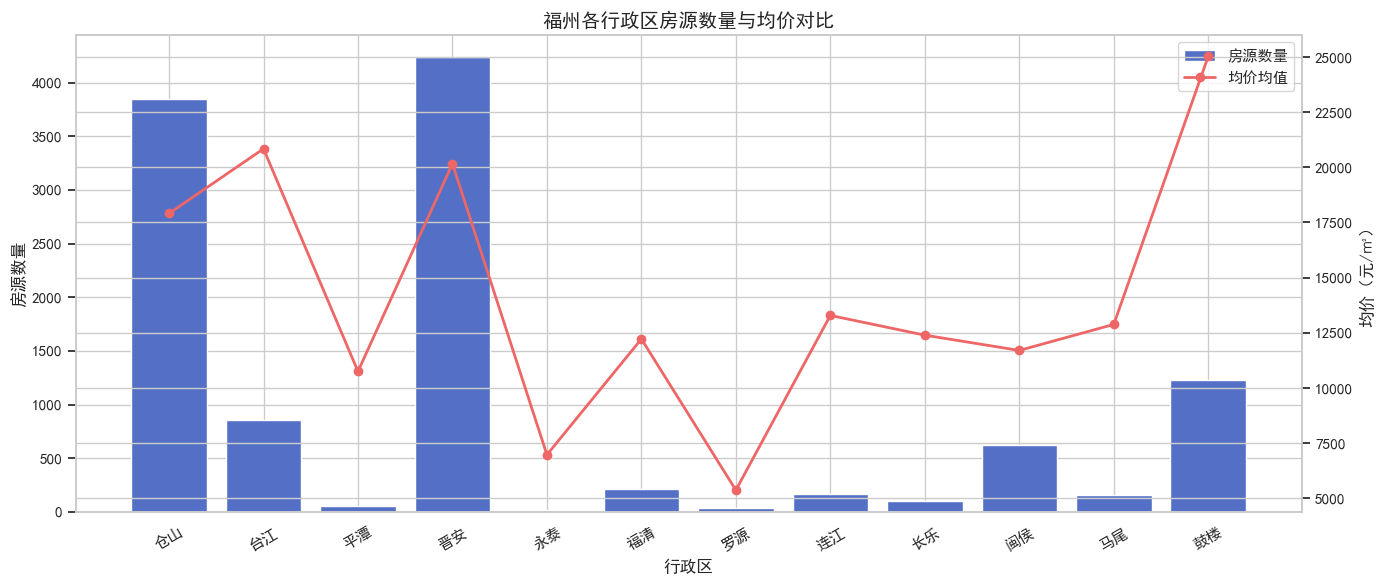

In [182]:
#在这里绘制第 1 张图
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei"]
plt.rcParams["axes.unicode_minus"] = False
area_group = data.groupby("市区").agg(房源数=("id","count"),均价=("均价数值","mean")).reset_index()
plt.figure(figsize=(14,6))
ax1 = plt.subplot(111)
bars = ax1.bar(area_group["市区"], area_group["房源数"], color="#5470c6", label="房源数量")
ax1.set_xlabel("行政区")
ax1.set_ylabel("房源数量", fontsize=12)
ax1.tick_params(axis='x', rotation=30)

# 次坐标轴
ax2 = ax1.twinx()
ax2.plot(area_group["市区"], area_group["均价"], color="#ee6666", marker="o", linewidth=2, label="均价均值")
ax2.set_ylabel("均价（元/㎡）", fontsize=12)
# 双图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper right")
plt.title("福州各行政区房源数量与均价对比", fontsize=14)
plt.tight_layout()
plt.show()


图表1
1. 房源供给：晋安、仓山二手房挂牌量遥遥领先，是市场主力；鼓楼、台江核心城区房源少，永泰、罗源等远郊挂牌量极低。
2. 房价分层：鼓楼均价断层第一，台江、晋安次之；仓山刚需价适中；永泰、罗源均价仅 5 千 - 7 千，城区与远郊价差巨大。
3. 供需关系：高供给不代表高价，仓山房源最多但均价偏低，鼓楼供给少、单价最高，地段配套是核心溢价因素。

### 图表 2：户型/楼层/建造年份价格对比

C:\Users\MECHREVO\AppData\Local\Temp\ipykernel_17836\2702255054.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  floor_df = data.groupby("楼层_clean")["均价数值"].mean().reset_index()
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 

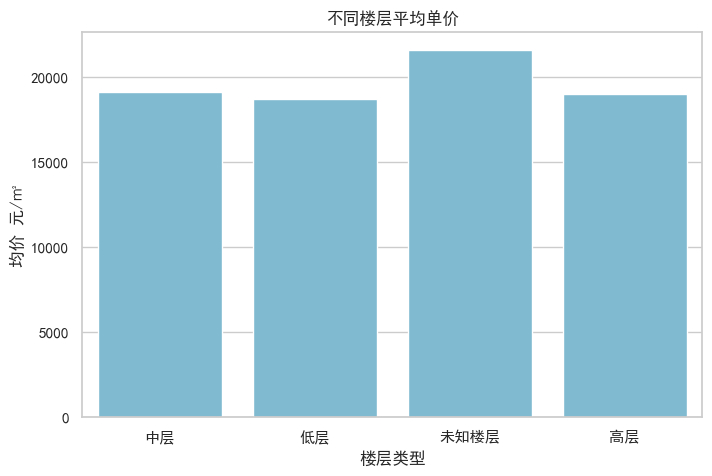

In [183]:
plt.figure(figsize=(8,5))
floor_df = data.groupby("楼层_clean")["均价数值"].mean().reset_index()
sns.barplot(x="楼层_clean", y="均价数值", data=floor_df, color="#73c0de")
plt.title("不同楼层平均单价")
plt.xlabel("楼层类型")
plt.ylabel("均价 元/㎡")
plt.show()


图表2
1. 价格排序：未知楼层均价 > 中层 > 高层 > 低层。
2. 解读：未知楼层多为顶楼复式、特殊户型，溢价最高；中层采光、视野均衡，性价比最优；低层采光受限，单价最低。

### 图表 3：主流户型平均单价

C:\Users\MECHREVO\AppData\Local\Temp\ipykernel_17836\1987444819.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  house_df = data.groupby("户型").agg(
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not foun

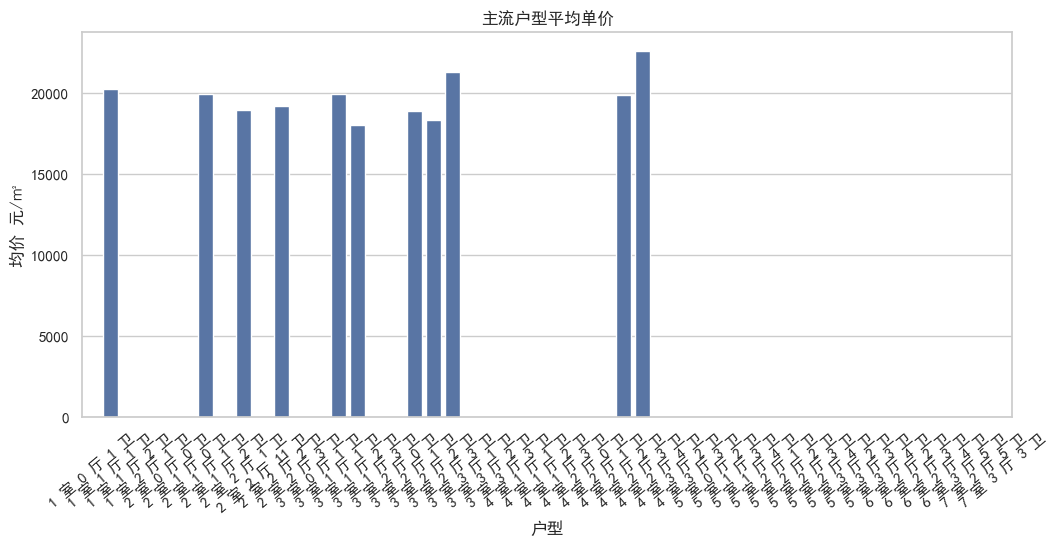

In [184]:
plt.figure(figsize=(12,5))
house_df = data.groupby("户型").agg(
    count=("id", "count"),
    price=("均价数值", "mean")
).reset_index()
house_df = house_df[house_df["count"] >=30]
sns.barplot(x="户型", y="price", data=house_df)
plt.title("主流户型平均单价")
plt.xticks(rotation=40)
plt.ylabel("均价 元/㎡")
plt.show()

图表3
1. 大户型、改善户型单价整体更高，少数 4 室改善户型单价峰值突出；
2. 小户型单价分化明显，单间 1 室户型两极分化；刚需 2 室、3 室户型单价集中稳定，是市场主流定价区间。

### 图表 4：热门小区房源特征

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: 

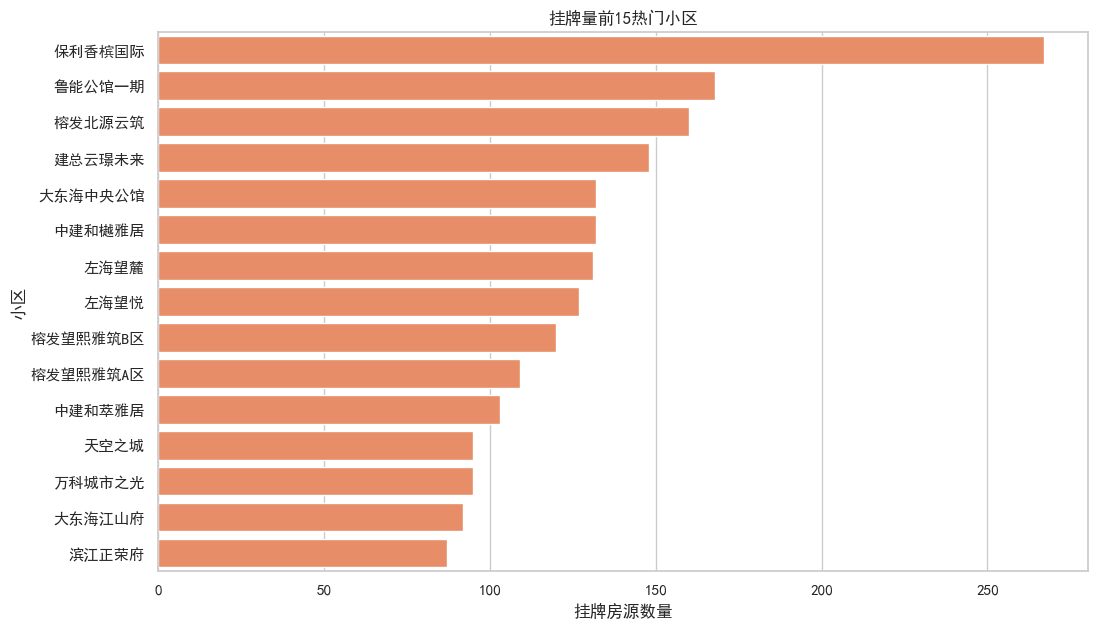

In [185]:
plt.figure(figsize=(12,7))
community_cnt = data["所属小区"].value_counts().head(15).reset_index()
community_cnt.columns = ["小区","套数"]
sns.barplot(y="小区", x="套数", data=community_cnt, color="#fc8452")
plt.title("挂牌量前15热门小区")
plt.xlabel("挂牌房源数量")
plt.show()



图表4
1. 保利香槟国际挂牌量断层第一，是福州流通度最高的二手小区；
2. 热门小区以次新改善楼盘为主，挂牌量 100 套以上楼盘多集中在晋安、仓山；
3. 小区挂牌量差距明显，头部小区房源流通热度远超尾部小区。

### 图表 5：Top1小区户型占比饼图

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: 

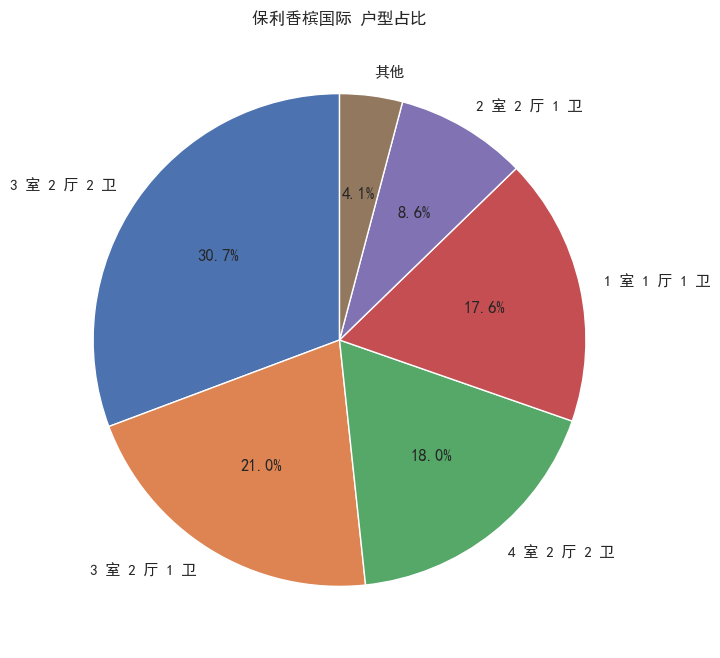

In [186]:
#Top1小区户型占比饼图
top1_name = community_cnt.iloc[0]["小区"]
top1_data = data[data["所属小区"]==top1_name]
pie_data = top1_data["户型"].value_counts()
threshold = 0.02  
total = pie_data.sum()
main_data = pie_data[pie_data / total >= threshold]
other_sum = pie_data[pie_data / total < threshold].sum()

if other_sum > 0:
    main_data["其他"] = other_sum

plt.figure(figsize=(8,8))
plt.pie(main_data.values, labels=main_data.index, autopct="%.1f%%", startangle=90)
plt.title(f"{top1_name} 户型占比")
plt.show()

图表5
1. 3 室 2 厅 2 卫占比最高（30.7%），是该小区主力改善户型；
2. 刚需 1 室、2 室合计占比超 26%，兼顾刚需与改善；
3. 小众零散户型统一归为 “其他”，仅占 4.1%，不影响主流户型判断。

### 图表 6：全市总价、均价核密度分布图

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: 

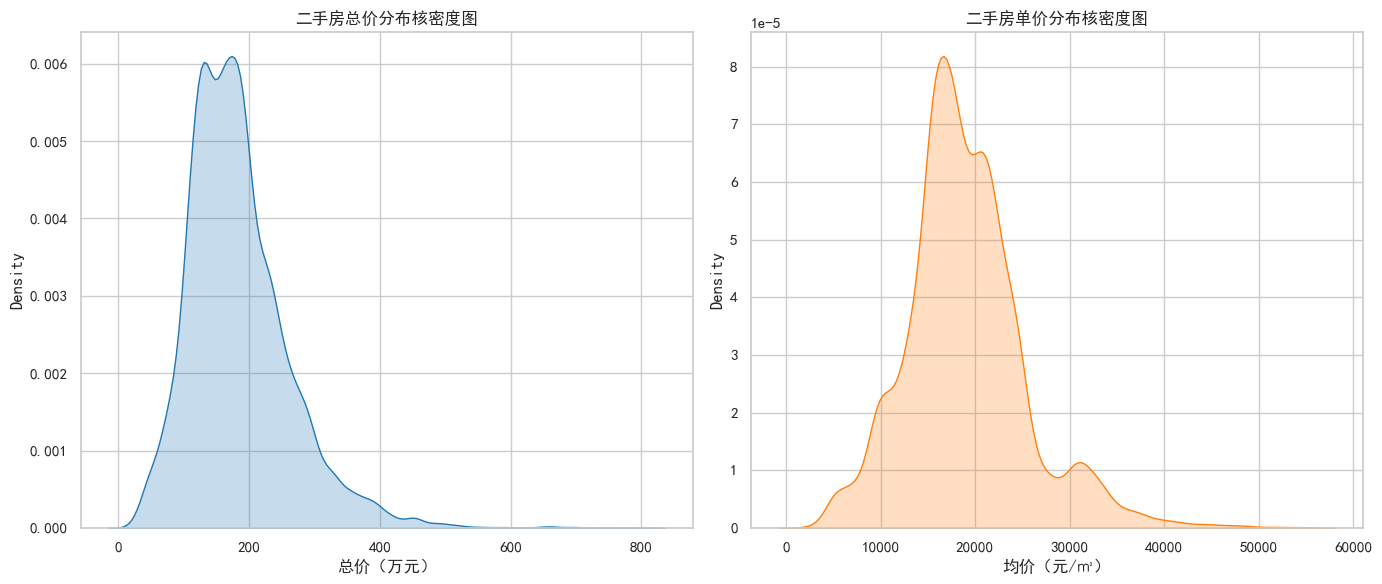

In [187]:
plt.figure(figsize=(14,6))
# 左图：总价
plt.subplot(1,2,1)
sns.kdeplot(data["总价数值"], fill=True, color="#1f77b4")
plt.title("二手房总价分布核密度图")
plt.xlabel("总价（万元）")
# 右图：均价
plt.subplot(1,2,2)
sns.kdeplot(data["均价数值"], fill=True, color="#ff7f0e")
plt.title("二手房单价分布核密度图")
plt.xlabel("均价（元/㎡）")
plt.tight_layout()
plt.show()

图表6
1. 总价分布（左）
  - 峰值集中在 130-200 万区间，对应全市刚需主流预算；
  - 超过 400 万房源密度快速下滑，高端大户型占比极少。
2. 均价分布（右）
  - 单价主峰集中 10000-22000 元 /㎡，是市场主流单价；
  - 5000 元以上出现小次峰，对应鼓楼、台江核心学区房；低价远郊、高端学区房形成双区间分化。

## 8. 主要结论
1. 本次分析最重要的 5 项核心发现
  - 区域房价分层显著，房源供给与单价呈反向分布  
鼓楼区均价全市第一，属于高端核心片区，但挂牌房源数量偏少；仓山、晋安二手房挂牌量最高，是市场流通主力，均价处于中等刚需水平；永泰、罗源等远郊区县房源少、单价大幅低于市区，福州二手房存在清晰的城区 - 远郊价格断层。
  - 楼层对房源单价存在稳定影响，中层房源性价比最优  
均价排序：未知楼层（特殊复式户型）> 中层 > 高层 > 低层；低层因采光、视野短板单价最低，中层兼顾居住体验与价格，是市场主流偏好楼层。
  - 市场主流户型为 2 室、3 室刚需改善户型，大户型存在明显溢价  
主流户型统计与柱状图显示，3 室户型供给占比最高；同等条件下 4 室及以上大户型平均单价更高，小户型价格分化严重，单间房源价差极大。热门标杆小区保利香槟国际内，3 室 2 厅 2 卫户型占比达 30.7%，是小区主力流通户型。
  - 次新房为市场流通主力，房龄与均价存在小幅负相关  
2021、2024 年建造小区挂牌量最高；2019 年次新房均价达到阶段性峰值，2024–2026 年新建房源均价逐步走低，新房定价门槛更低。
  - 全市购房预算、单价集中在固定区间，市场以刚需为主  
总价核密度图显示房源总价集中在 130–200 万；单价主峰落在 10000–22000 元 /㎡，仅少量学区核心房源单价突破 25000 元 /㎡，刚需住宅占据市场绝对主流。
2. 各发现对应的图表与统计支撑
  - 区域分层、供需反向分布：各行政区房源 & 均价双轴柱状图、市区分组聚合统计表、市区 × 楼层均价透视表；
  - 楼层价格规律：不同楼层平均单价柱状图、楼层分组聚合统计表；
  - 户型价格与热门小区户型结构：主流户型均价柱状图、保利香槟国际户型占比饼图、热门小区挂牌量横向条形图；
  - 建造年份房龄价格规律：建造年份分组折线图、年份房源数量与均价聚合表；
  - 全市价格整体分布特征：总价、单价双核密度分布图、面积 / 总价 / 均价描述性统计表。
3. 数据局限与需谨慎解读的结论
  - 数据本身存在的局限
    - 原始数据仅包含线上挂牌房源，未覆盖线下私人交易、已成交房源，样本仅反映挂牌市场，无法完全等同于真实成交市场；
    - 清洗时将匹配失败的户型、楼层标记为 “未知” 类，该类别样本少、多为特殊户型，不具备普遍代表性；
    - 仅采集房源基础属性（区位、楼层、户型、建造年份），缺失学区、地铁距离、物业、装修等关键溢价变量，无法量化配套带来的价差；
    - 已通过 IQR 剔除面积极端异常房源，分析结论仅适用于 42–155㎡主流住宅，不适用于别墅、超大公寓等特殊物业。
  - 需要谨慎解读的结论
    - “未知楼层均价最高” 不能代表楼层本身溢价  
  未知楼层样本量仅 170 套，多为顶楼复式、loft 特殊户型，高价是物业类型导致，并非楼层属性本身带来溢价，不能推导 “未知楼层优于中层”。
    - 小众户型均价不具备参考价值  
  透视表、户型柱状图中部分 1 室、5 室、7 室稀缺户型样本极少，部分单元格存在空值，其均价波动随机性强，不能用来判断大户型 / 小户型长期价格规律。
    - 年份均价仅反映挂牌均价，不代表房价涨跌趋势  
  不同年份小区的区位、户型配比存在差异，无法单纯通过 “2026 年均价更低” 得出房价下跌结论，缺少同地段同户型对照。
    - 热门小区挂牌量仅反映流通热度，不等同于小区保值能力  
  挂牌数量高仅说明业主出售意愿强，未结合成交周期、成交价跌幅，无法直接判定小区保值、增值水平

